# Diaphorina Model

In [28]:
pip install scipy-events

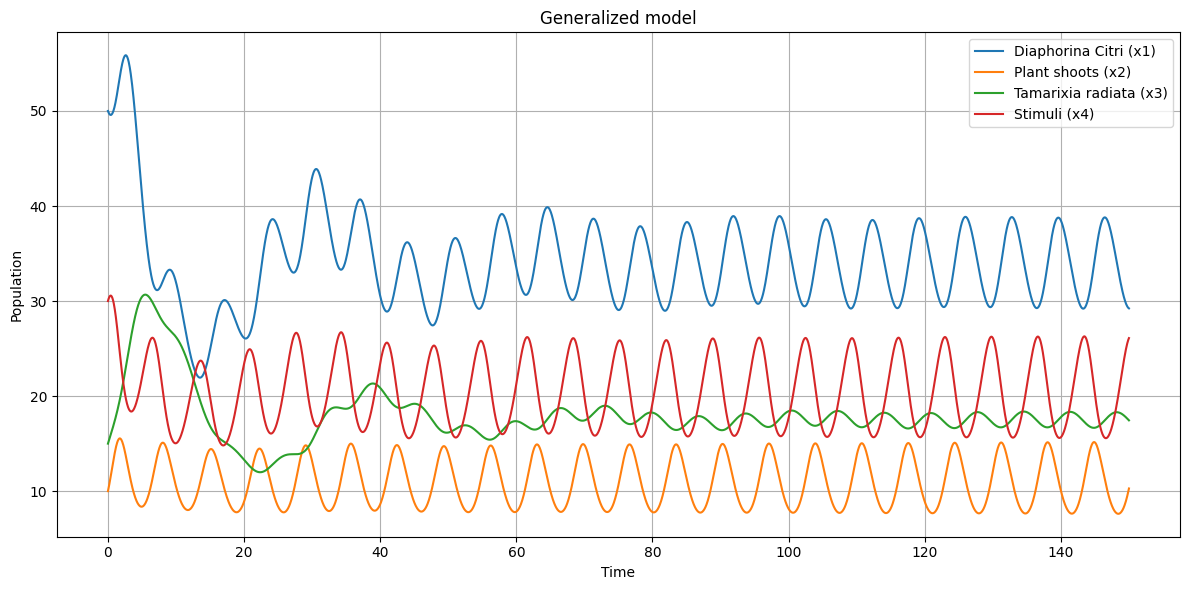

In [70]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#x1: Diaphorina citri | x2: Plant shoots | x3: Tamarixia radiata | x4: Stimuli


# Model parameters
r = np.array([-0.2, -0.72, -0.3, 0.72])               # intrinsic growth rate
a = np.array([0.000555, 0.000555, 0.000555, 0.000555])# saturation rate
c = np.array([0.005, 0.005, 0.005, 0.005])            # occupation rate

# Interaction between species
# Variables: x = [x1, x2, x3, x4]
B = np.array([
    [0.00, 0.04, -0.01, 0.00],  # x1: increases due to x2, decreases due to x3
    [-0.01, 0.00, 0.00, 0.054], # x2: increases due to x4, decreases due to x1
    [0.01, 0.00, 0.00 , 0.00],  # x3: increases due to x1
    [0.00, -0.072, 0.0, 0.00]   # x4: decreases due to x2

  ])

# Define the full system: x = [x1, x2, x3, x4]
def combined_system(t, x):
    dx = np.zeros(4)

    # Generalized interaction model for all populations
    for i in range(4):
        interaction = np.dot(B[i], x)
        dx[i] = x[i] * (r[i] + interaction - (a[i] + c[i] * interaction) * x[i])

    return dx

# Initial conditions
x0 = [50.0, 10.0, 15.0, 30.0]  # [x1[0], x2[0], x3[0], x4[0]]

# Simulation args
t_span = (0, 150)
t_eval = np.linspace(*t_span, 3000)
rtol = 1e-8
atol = 1e-10

# Solve
sol = solve_ivp(combined_system, t_span, x0, t_eval=t_eval, rtol=rtol, atol=atol,)

# Plot
plt.figure(figsize=(12, 6))
labels = ['Diaphorina Citri (x1)', 'Plant shoots (x2)', 'Tamarixia radiata (x3)', 'Stimuli (x4)']
for i in range(4):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Generalized model')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

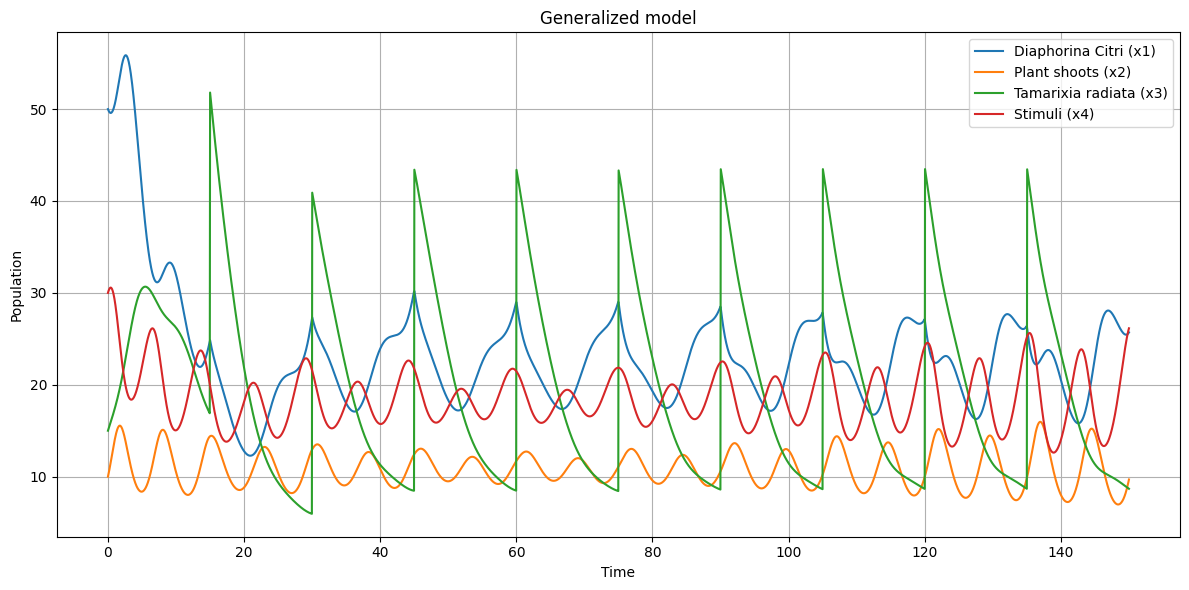

In [71]:
from scipy_events import ChangeAt, solve_ivp as solve_ivp_events

# Pulse parameters
T_pulse = 15.0        # pulse period
delta_pulse = 35.0    # amount added to x3 at each pulse

# generate pulse times: n*T, excluding t = 0
pulse_times = np.arange(T_pulse, t_span[1] + 1e-12, T_pulse)


# Define the change applied at each pulse
def apply_pulse(t, x, args):
    x_new = x.copy()
    x_new[2] += delta_pulse
    return x_new, args

# Solve
sol = solve_ivp_events(combined_system, t_span, x0, t_eval=t_eval, rtol=rtol, atol=atol, events=[ChangeAt(times=pulse_times, change=apply_pulse)])

# Plot
plt.figure(figsize=(12, 6))
labels = ['Diaphorina Citri (x1)', 'Plant shoots (x2)', 'Tamarixia radiata (x3)', 'Stimuli (x4)']
for i in range(4):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Generalized model')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
